In [31]:
import numpy as np
import matplotlib.pyplot as plt
import librosa as lb

### Reading alignment output

Default settings:
hopTime = 0.02 seconds
With sample rate 22050Hz, there will be 441 samples per frame

In [ ]:
dumpfile_dir = "/Users/server/Desktop/match/dump_features_testagain.txt" 
# change this to the path of the dump file
with open(dumpfile_dir, 'r') as file:
    lines = [line.strip() for line in file if line.strip()]

alignment_data = []
for e in lines:
    if e.startswith("ALIGNMENT"):
        e = e.split(" ")
        alignment_data.append((int(e[1][0:-1]), int(e[2])))



In [73]:
query_dir = "/Users/server/Desktop/match/wav/bach5_mov1_S_tsm.wav"
ref_dir = "/Users/server/Desktop/match/wav/bach5_mov1_S.wav"
query_y, _ = lb.load(query_dir)
ref_y, _ = lb.load(ref_dir)

In [74]:
print(f"Query length (in frames): {int(len(query_y)/441)}")
print(f"Reference length (in frames): {int(len(ref_y)/441)}")

Query length (in frames): 5002
Reference length (in frames): 10004


/opt/miniconda3/envs/E207_Spr25/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


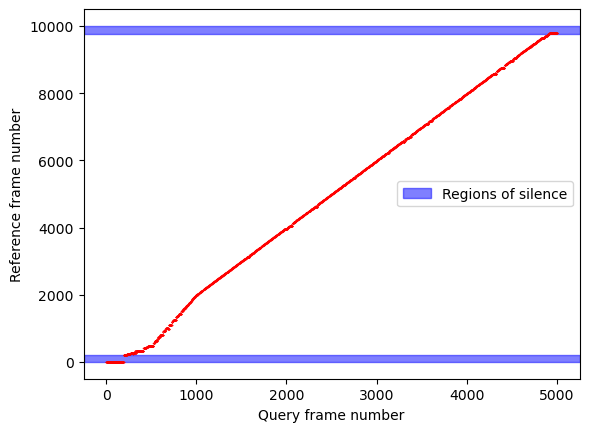

In [75]:
for e in alignment_data:
    plt.plot(e[0], e[1], 'ro', markersize=0.2)
# plt.title("Alignment")
plt.xlabel("Query frame number")
plt.ylabel("Reference frame number")
plt.axhspan(ymin=195.4* 22050 / 441, ymax=len(ref_y)/441, color='blue', alpha=0.5)
plt.axhspan(ymin=0, ymax=3.9*22050 / 441, color='blue', alpha=0.5, label='Regions of silence')
plt.legend()
plt.show()

Checking with offline_alignment.txt

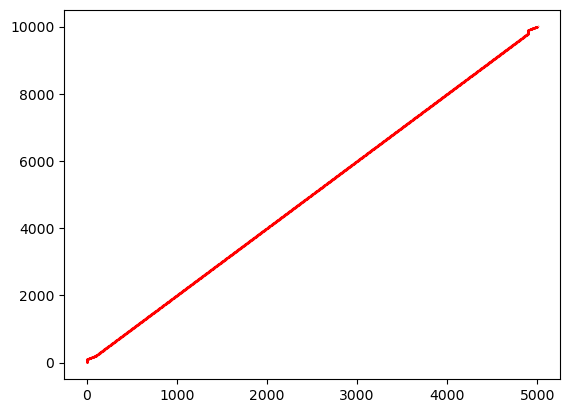

In [71]:
alignment_dir = "/Users/server/Desktop/match/alignment_path.txt"
alignment_data = []
with open(alignment_dir, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            x1, x2 = map(float, parts)
            alignment_data.append((x1, x2))
alignment_data.sort(reverse=True)
for e in alignment_data:
    plt.plot(e[0]*22050 / 441, e[1]*22050 / 441, 'ro', markersize=0.2)
plt.show()
